In [111]:
# =========================
# STEP 1: LOAD DATA
# =========================

import pandas as pd
import numpy as np

df = pd.read_csv("ipl_matches.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (283678, 65)


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,141609,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,141610,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,3,0,NaN,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,141611,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,4,0,NaN,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [112]:
# =========================
# STEP 2: MATCH LEVEL DATA
# =========================

df_ipl = df[df['event_name'] == 'Indian Premier League']

match_df = df_ipl.groupby('match_id').agg({
    'season': 'first',
    'batting_team': 'first',
    'bowling_team': 'first',
    'toss_winner': 'first',
    'toss_decision': 'first',
    'venue': 'first',
    'city': 'first',
    'match_won_by': 'first'
}).reset_index()

match_df.rename(columns={
    'batting_team': 'team1',
    'bowling_team': 'team2',
    'match_won_by': 'winner'
}, inplace=True)

match_df = match_df.dropna(subset=['winner']).reset_index(drop=True)

print("Match-level Shape:", match_df.shape)
match_df.head()

Match-level Shape: (1193, 9)


,match_id,season,team1,team2,toss_winner,toss_decision,venue,city,winner
0,335982,2007/08,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,Kolkata Knight Riders
1,335983,2007/08,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Chennai Super Kings
2,335984,2007/08,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,Feroz Shah Kotla,Delhi,Delhi Daredevils
3,335985,2007/08,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Wankhede Stadium,Mumbai,Royal Challengers Bangalore
4,335986,2007/08,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,Eden Gardens,Kolkata,Kolkata Knight Riders


In [113]:
# =========================
# STEP 3: CLEAN TEAMS
# =========================

team_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': None,
    'Rising Pune Supergiants': None,
    'Pune Warriors': None,
    'Kochi Tuskers Kerala': None,
    'Gujarat Lions': None,
    'Deccan Chargers': None
}

match_df['team1'] = match_df['team1'].replace(team_map)
match_df['team2'] = match_df['team2'].replace(team_map)
match_df['winner'] = match_df['winner'].replace(team_map)

match_df = match_df.dropna(subset=['team1', 'team2', 'winner'])

active_teams = [
    'Chennai Super Kings',
    'Mumbai Indians',
    'Kolkata Knight Riders',
    'Royal Challengers Bengaluru',
    'Delhi Capitals',
    'Punjab Kings',
    'Rajasthan Royals',
    'Sunrisers Hyderabad',
    'Gujarat Titans',
    'Lucknow Super Giants'
]

match_df = match_df[
    match_df['team1'].isin(active_teams) &
    match_df['team2'].isin(active_teams) &
    match_df['winner'].isin(active_teams)
].reset_index(drop=True)

print("Teams:", sorted(set(match_df['team1']).union(set(match_df['team2']))))

Teams: ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [114]:
# =========================
# STEP 4: FIX SEASON
# =========================

match_df['season'] = match_df['season'].astype(str).str[:4].astype(int)

In [115]:
# =========================
# STEP 5: ELO RATING
# =========================

teams = list(set(match_df['team1']).union(set(match_df['team2'])))

elo = {team: 1500 for team in teams}

def expected(r1, r2):
    return 1 / (1 + 10 ** ((r2 - r1) / 400))

match_df = match_df.sort_values(by='season')

for _, row in match_df.iterrows():
    t1, t2 = row['team1'], row['team2']
    winner = row['winner']
    
    r1, r2 = elo[t1], elo[t2]
    
    e1, e2 = expected(r1, r2), expected(r2, r1)
    
    if winner == t1:
        elo[t1] += 32 * (1 - e1)
        elo[t2] += 32 * (0 - e2)
    else:
        elo[t1] += 32 * (0 - e1)
        elo[t2] += 32 * (1 - e2)

print("ELO Ratings Ready ✅")

ELO Ratings Ready ✅


In [116]:
# =========================
# STEP 6: SIMULATION FUNCTION
# =========================

import random
import copy

def run_simulation(base_elo):
    
    elo_sim = copy.deepcopy(base_elo)
    teams = list(elo_sim.keys())
    
    points = {team: 0 for team in teams}
    nrr = {team: 0 for team in teams}
    
    def predict(t1, t2, home):
        r1, r2 = elo_sim[t1], elo_sim[t2]
        
        prob = 1 / (1 + 10 ** ((r2 - r1) / 400))
        
        if home == t1:
            prob += 0.03
        else:
            prob -= 0.03
        
        prob = max(0.2, min(0.8, prob))
        
        return t1 if random.random() < prob else t2
    
    fixtures = []
    for i in range(len(teams)):
        for j in range(i+1, len(teams)):
            fixtures.append((teams[i], teams[j], teams[i]))
            fixtures.append((teams[j], teams[i], teams[j]))
    
    random.shuffle(fixtures)
    
    for t1, t2, home in fixtures:
        winner = predict(t1, t2, home)
        points[winner] += 2
        
        margin = random.uniform(0.1, 0.8)
        
        if winner == t1:
            nrr[t1] += margin
            nrr[t2] -= margin
        else:
            nrr[t2] += margin
            nrr[t1] -= margin
        
        # ELO update
        if winner == t1:
            elo_sim[t1] += 5
            elo_sim[t2] -= 5
        else:
            elo_sim[t2] += 5
            elo_sim[t1] -= 5
    
    table = sorted(points.items(), key=lambda x: (x[1], nrr[x[0]]), reverse=True)
    
    top4 = [team for team, _ in table[:4]]
    
    def play(a, b):
        return predict(a, b, a)
    
    q1 = play(top4[0], top4[1])
    q1_l = top4[1] if q1 == top4[0] else top4[0]
    
    elim = play(top4[2], top4[3])
    q2 = play(q1_l, elim)
    
    champion = play(q1, q2)
    
    return champion, tuple(top4)


🏆 WINNER PROBABILITY:

Royal Challengers Bengaluru: 47.12%
Punjab Kings: 21.75%
Gujarat Titans: 11.12%
Rajasthan Royals: 6.0%
Sunrisers Hyderabad: 3.38%
Delhi Capitals: 3.12%
Lucknow Super Giants: 3.12%
Mumbai Indians: 1.62%
Chennai Super Kings: 1.5%
Kolkata Knight Riders: 1.25%

🔥 MOST COMMON TOP 4:

('Royal Challengers Bengaluru', 'Gujarat Titans', 'Punjab Kings', 'Rajasthan Royals') -> 9
('Royal Challengers Bengaluru', 'Gujarat Titans', 'Punjab Kings', 'Sunrisers Hyderabad') -> 8
('Royal Challengers Bengaluru', 'Punjab Kings', 'Gujarat Titans', 'Sunrisers Hyderabad') -> 7

🏏 QUALIFIER 1: Royal Challengers Bengaluru vs Gujarat Titans
🏏 ELIMINATOR: Punjab Kings vs Rajasthan Royals

🏏 PREDICTED FINAL PATH:
Qualifier 2: Gujarat Titans vs Punjab Kings
Final: Royal Challengers Bengaluru vs Punjab Kings

📊 MODEL CONFIDENCE:
Royal Challengers Bengaluru dominates with 47.12% probability


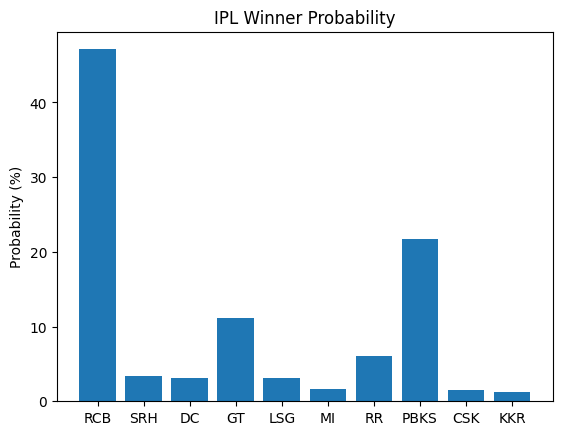

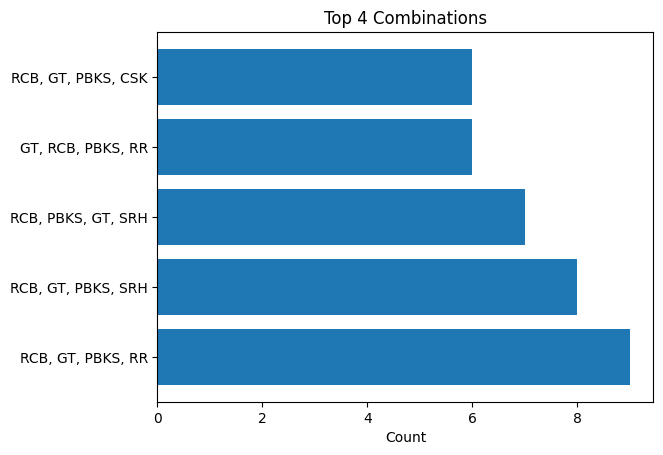

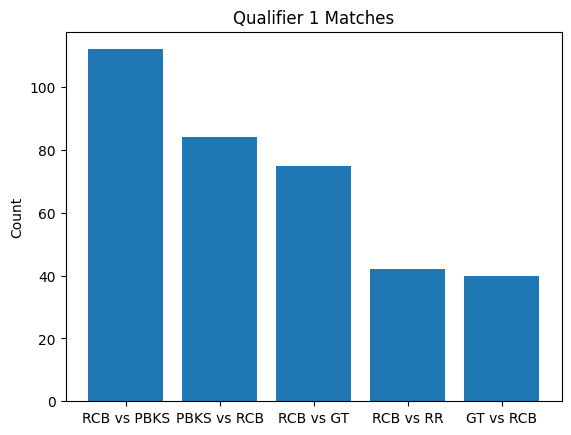

In [117]:
# =========================
# STEP 7: MONTE CARLO + PLAYOFFS + FINAL PATH + GRAPHS
# =========================

from collections import Counter
import matplotlib.pyplot as plt

SIMS = 800

winner_count = Counter()
top4_count = Counter()
q1_count = Counter()
elim_count = Counter()

# -------------------------
# TEAM SHORT NAMES
# -------------------------
short_names = {
    'Chennai Super Kings': 'CSK',
    'Mumbai Indians': 'MI',
    'Kolkata Knight Riders': 'KKR',
    'Royal Challengers Bengaluru': 'RCB',
    'Delhi Capitals': 'DC',
    'Punjab Kings': 'PBKS',
    'Rajasthan Royals': 'RR',
    'Sunrisers Hyderabad': 'SRH',
    'Gujarat Titans': 'GT',
    'Lucknow Super Giants': 'LSG'
}

# -------------------------
# RUN SIMULATION
# -------------------------
for _ in range(SIMS):
    champion, top4 = run_simulation(elo)
    
    winner_count[champion] += 1
    top4_count[top4] += 1
    
    t1, t2, t3, t4 = top4
    
    q1_count[(t1, t2)] += 1
    elim_count[(t3, t4)] += 1

# -------------------------
# PRINT RESULTS
# -------------------------

print("\n🏆 WINNER PROBABILITY:\n")
for team, count in winner_count.most_common():
    print(f"{team}: {round((count/SIMS)*100,2)}%")

print("\n🔥 MOST COMMON TOP 4:\n")
for combo, count in top4_count.most_common(3):
    print(combo, "->", count)

# -------------------------
# PLAYOFF MATCHES
# -------------------------

t1, t2, t3, t4 = top4_count.most_common(1)[0][0]

print("\n🏏 QUALIFIER 1:", t1, "vs", t2)
print("🏏 ELIMINATOR:", t3, "vs", t4)

# -------------------------
# FINAL PATH (NEW 🔥)
# -------------------------

print("\n🏏 PREDICTED FINAL PATH:")

# Q1 winner (based on ELO)
q1_winner = t1 if elo[t1] > elo[t2] else t2
q1_loser = t2 if q1_winner == t1 else t1

# Eliminator winner
elim_winner = t3 if elo[t3] > elo[t4] else t4

# Qualifier 2
print("Qualifier 2:", q1_loser, "vs", elim_winner)

# Final
print("Final:", q1_winner, "vs", elim_winner)

print("\n📊 MODEL CONFIDENCE:")
top_team, top_prob = winner_count.most_common(1)[0]
print(f"{top_team} dominates with {round(top_prob/SIMS*100,2)}% probability")

# -------------------------
# GRAPHS
# -------------------------

# Winner Probability
teams = list(winner_count.keys())
probs = [winner_count[t] / SIMS * 100 for t in teams]
labels = [short_names[t] for t in teams]

plt.figure()
plt.bar(labels, probs)
plt.title("IPL Winner Probability")
plt.ylabel("Probability (%)")
plt.show()

# Top 4 Graph
top4_labels = [
    ", ".join([short_names[t] for t in combo])
    for combo, _ in top4_count.most_common(5)
]
top4_vals = [v for _, v in top4_count.most_common(5)]

plt.figure()
plt.barh(top4_labels, top4_vals)
plt.title("Top 4 Combinations")
plt.xlabel("Count")
plt.show()

# Qualifier 1 Graph
q1_labels = [
    f"{short_names[a]} vs {short_names[b]}"
    for (a, b), _ in q1_count.most_common(5)
]
q1_vals = [v for _, v in q1_count.most_common(5)]

plt.figure()
plt.bar(q1_labels, q1_vals)
plt.title("Qualifier 1 Matches")
plt.ylabel("Count")
plt.show()


import json

with open("results.json", "w") as f:
    json.dump(winner_count, f)
